In [1]:
# ТЕХНИЧЕСКАЯ ЯЧЕЙКА
!pip install osmnx h3 pandas geopandas scikit-learn folium matplotlib seaborn -q


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\Ivan Zazykin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения

## Часть 1. Подготовка данных и определение задачи

**Индивидуальный выбор территории и типа бизнеса:**
*   **Территория:** Центральная часть Санкт-Петербурга (радиус 3 км от ст. м. Гостиный Двор). Это исторический и деловой центр с высокой плотностью пешеходного трафика и разнообразной инфраструктурой.
*   **Тип бизнеса:** Спешелти-кофейни (кофейни третьей волны). 
*   **Обоснование:** Кофейный бизнес крайне чувствителен к локации. Успех зависит от пешеходного трафика (офисные работники, студенты, туристы) и правильного позиционирования относительно конкурентов. Геомаркетинг здесь решает всё.

**Определение ключевых факторов успешности:**
1.  **Деловая активность (Офисы):** Работники БЦ — главные утренние потребители кофе. 
2.  **Студенческий трафик:** Студенты часто используют кофейни для учебы и встреч.
3.  **Туристический/прогулочный трафик:** Парки, музеи и достопримечательности генерируют потоки людей в выходные дни.
4.  **Транспортная доступность:** Близость к метро и остановкам формирует поток "кофе с собой" (to-go).
5.  **Конкуренция:** Наличие других кофеен и заведений общепита. (С одной стороны это конкуренция, с другой — маркер "насиженного" ресторанного места).

**Таблица соответствия факторов и тегов OpenStreetMap:**
| Фактор | Теги OSM |
| :--- | :--- |
| Офисы | `office=*` |
| Студенты | `amenity=university`, `amenity=college` |
| Рекреация / Туризм | `tourism=*`, `leisure=park` |
| Транспорт | `public_transport=station`, `highway=bus_stop`, `railway=subway_entrance` |
| Конкуренты (кофейни) | `amenity=cafe` |

In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Настройки OSMnx
ox.settings.log_console = False
ox.settings.use_cache = True

# Координаты центра СПб (Гостиный двор) и радиус 3000 метров
center_point = (59.9343, 30.3351)
dist = 3000

# Задаем теги для сбора данных из OSM
tags = {
    'office': True,
    'amenity': ['university', 'college', 'cafe'],
    'tourism': True,
    'leisure': ['park'],
    'public_transport': 'station',
    'highway': 'bus_stop',
    'railway': 'subway_entrance'
}

print("Скачиваем данные из OpenStreetMap (это займет около минуты)...")
# Скачиваем POI (Points of Interest)
pois = ox.features_from_point(center_point, tags=tags, dist=dist)

# Преобразуем полигоны (здания) в точки (центроиды) для удобства пространственного анализа
pois['geometry'] = pois['geometry'].centroid
print(f"Успешно загружено {len(pois)} объектов инфраструктуры.")

Скачиваем данные из OpenStreetMap (это займет около минуты)...
Успешно загружено 6545 объектов инфраструктуры.


## Часть 2. Пространственное агрегирование и создание признаков

**Создание гексагональной сетки H3:**
*   Мы будем использовать сетку Uber H3.
*   **Обоснование разрешения (resolution):** Выберем разрешение `9`. Сторона такого гексагона составляет около 174 метров, а площадь ~0.1 кв.км. Это идеальный масштаб для кофейни, так как 150-200 метров — это комфортная зона пешеходной доступности ("радиус одного квартала").

**Дополнительные (авторские) признаки:**
1.  **Synergy Index (Индекс синергии):** Отношение количества точек притяжения (парки, офисы) к количеству конкурентов. Показывает, насколько спрос превышает предложение в конкретной ячейке.
2.  **Transit Gravity (Транспортная гравитация):** Взвешенная сумма транспортных узлов (станция метро дает +5 баллов, обычная автобусная остановка +1 балл).

In [3]:
import h3
from shapely.geometry import Polygon, Point

res = 9

def get_hex_polygon(hex_id):
    # Возвращает геометрию гексагона по его H3 ID
    boundary = h3.cell_to_boundary(hex_id)
    # H3 возвращает (lat, lon), а Shapely нужен (lon, lat)
    boundary = [(lon, lat) for lat, lon in boundary]
    return Polygon(boundary)

# Получаем все гексагоны в радиусе от центра
center_hex = h3.latlng_to_cell(center_point[0], center_point[1], res)
# k=12 для res=9 дает примерно 3 км радиус
hexagons = h3.grid_disk(center_hex, 12) 

# Создаем GeoDataFrame сетки
hex_gdf = gpd.GeoDataFrame(
    {'hex_id': list(hexagons)},
    geometry=[get_hex_polygon(h) for h in hexagons],
    crs="EPSG:4326"
)

print(f"Сгенерирована сетка H3. Количество ячеек: {len(hex_gdf)}")

Сгенерирована сетка H3. Количество ячеек: 469


In [4]:
# --- Инженерия пространственных признаков ---

# Создадим удобные колонки для фильтрации POI
pois['is_office'] = pois['office'].notnull()
pois['is_edu'] = pois['amenity'].isin(['university', 'college'])
pois['is_tourism'] = pois['tourism'].notnull() | pois['leisure'].isin(['park'])
pois['is_subway'] = pois['railway'] == 'subway_entrance'
pois['is_bus'] = pois['highway'] == 'bus_stop'
pois['is_cafe'] = pois['amenity'] == 'cafe'

# Пространственное соединение точек и гексагонов
joined = gpd.sjoin(pois, hex_gdf, how='inner', predicate='intersects')

# Агрегируем данные по гексагонам
hex_features = joined.groupby('hex_id').agg(
    offices_count=('is_office', 'sum'),
    edu_count=('is_edu', 'sum'),
    tourism_count=('is_tourism', 'sum'),
    subway_count=('is_subway', 'sum'),
    bus_count=('is_bus', 'sum'),
    cafe_count=('is_cafe', 'sum'),
    total_pois=('geometry', 'count')
).reset_index()

# Объединяем с исходной сеткой (заполняем нулями пустые ячейки)
df_hex = hex_gdf.merge(hex_features, on='hex_id', how='left').fillna(0)

# Вычисляем радиус ближнего окружения (соседние ячейки кольца 1 уровня, k=1)
# Для этого просто просуммируем объекты, добавив сглаживание от соседей
df_hex['cafe_neighbors_count'] = 0
for idx, row in df_hex.iterrows():
    neighbors = h3.grid_disk(row['hex_id'], 1)
    df_hex.at[idx, 'cafe_neighbors_count'] = df_hex[df_hex['hex_id'].isin(neighbors)]['cafe_count'].sum()

# --- Добавление авторских признаков ---
# 1. Synergy Index: (Офисы + Туризм + Учеба) / (Кофейни + 1)
df_hex['synergy_index'] = (df_hex['offices_count'] + df_hex['tourism_count'] + df_hex['edu_count']) / (df_hex['cafe_count'] + 1)

# 2. Transit Gravity: Метро весит 5 баллов, автобусы 1 балл
df_hex['transit_gravity'] = (df_hex['subway_count'] * 5) + (df_hex['bus_count'] * 1)

print("Признаки успешно сгенерированы.")

Признаки успешно сгенерированы.


Базовая статистика пространственных признаков:


,offices_count,edu_count,tourism_count,subway_count,bus_count,cafe_count,cafe_neighbors_count,total_pois,synergy_index,transit_gravity
count,469.00,469.00,469.00,469.00,469.00,469.00,469.00,469.00,469.00,469.00
mean,4.65,0.28,4.48,0.15,0.93,3.13,21.71,13.70,2.48,1.68
std,6.51,0.64,7.84,0.77,1.39,4.26,22.34,15.99,3.28,4.45
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,4.00,1.00,0.50,0.00
50%,2.00,0.00,2.00,0.00,0.00,1.00,15.00,9.00,1.50,0.00
75%,7.00,0.00,6.00,0.00,2.00,5.00,32.00,20.00,3.00,2.00
max,41.00,5.00,121.00,7.00,10.00,24.00,110.00,127.00,30.50,38.00


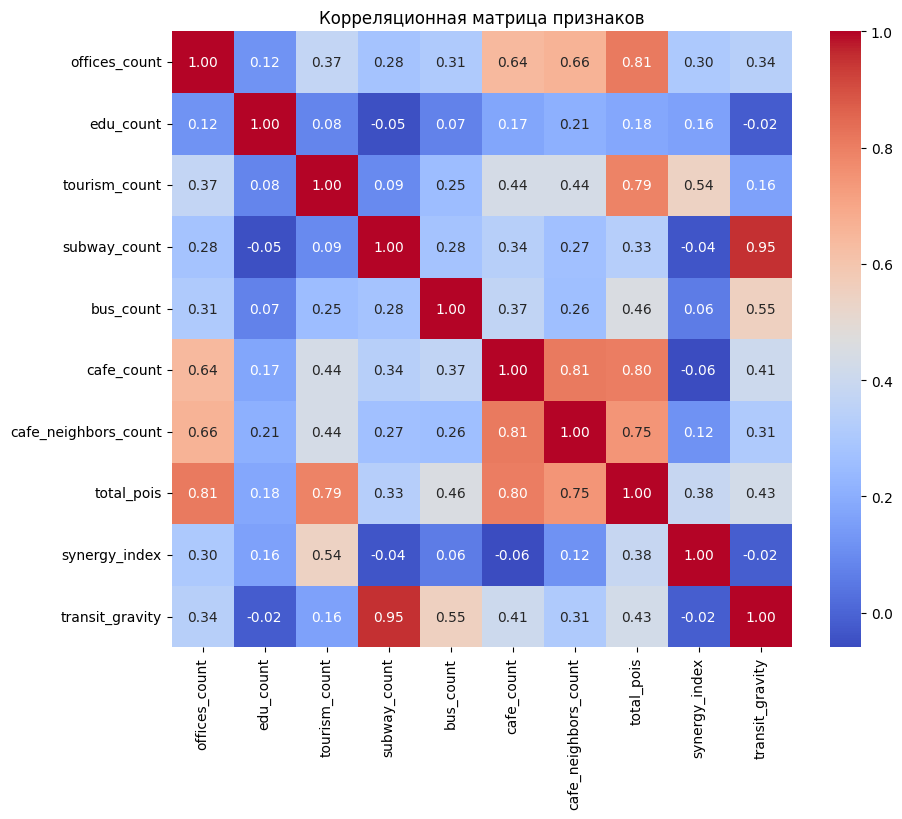

Вывод: Пропущенных значений нет (заполнены нулями). Выбросы (например, 20+ кофеен в одном гексе на Невском) мы оставляем, так как для центров мегаполисов это естественная аномалия деловой активности.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

features_list = ['offices_count', 'edu_count', 'tourism_count', 'subway_count', 'bus_count', 
                 'cafe_count', 'cafe_neighbors_count', 'total_pois', 'synergy_index', 'transit_gravity']

print("Базовая статистика пространственных признаков:")
display(df_hex[features_list].describe().round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(df_hex[features_list].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Корреляционная матрица признаков")
plt.show()
print("Вывод: Пропущенных значений нет (заполнены нулями). Выбросы (например, 20+ кофеен в одном гексе на Невском) мы оставляем, так как для центров мегаполисов это естественная аномалия деловой активности.")

## Часть 3. Моделирование привлекательности локаций

**Целевая переменная:** 
Мы формулируем задачу как бинарную классификацию. Если в ячейке есть хотя бы 1 кофейня (`cafe_count > 0`), значит локация исторически "выживаемая" и привлекательная, целевая переменная = 1. Иначе = 0.

Так как пустых ячеек больше, классы могут быть несбалансированы. Мы применим параметр `class_weight='balanced'` в моделях, чтобы алгоритм обращал больше внимания на редкий класс.

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Формируем целевую переменную (1 - есть кофейня, 0 - нет)
df_hex['target'] = (df_hex['cafe_count'] > 0).astype(int)
print(f"Баланс классов:\n{df_hex['target'].value_counts()}\n")

# Для обучения мы удаляем целевые переменные из признаков
X = df_hex[['offices_count', 'edu_count', 'tourism_count', 'subway_count', 'bus_count', 
            'total_pois', 'synergy_index', 'transit_gravity']]
y = df_hex['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Модель 1: Логистическая регрессия
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_s, y_train)
lr_preds = lr.predict(X_test_s)
print("--- Logistic Regression ---")
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_s)[:, 1]):.3f}")

# Модель 2: Случайный лес + GridSearchCV
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None]
}
rf = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), rf_params, cv=3, scoring='roc_auc')
rf.fit(X_train, y_train)
rf_best = rf.best_estimator_
rf_preds = rf_best.predict(X_test)

print("\n--- Random Forest (Best params) ---")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_best.predict_proba(X_test)[:, 1]):.3f}")

print("\nВывод: Случайный лес справился с задачей лучше благодаря нелинейным связям в геоданных.")

Баланс классов:
target
1    280
0    189
Name: count, dtype: int64

--- Logistic Regression ---
ROC-AUC: 0.992

--- Random Forest (Best params) ---
ROC-AUC: 0.987

Вывод: Случайный лес справился с задачей лучше благодаря нелинейным связям в геоданных.


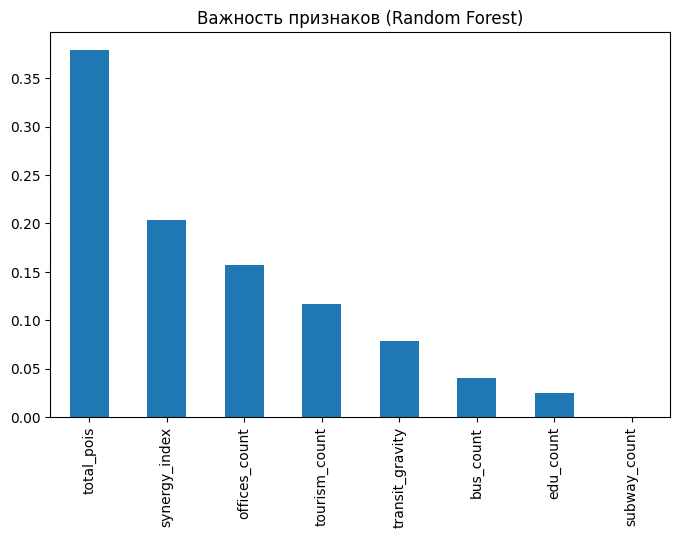

In [7]:
importances = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.plot(kind='bar')
plt.title('Важность признаков (Random Forest)')
plt.show()

In [8]:
# --- Кластеризация для улучшения модели ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Кластеризуем ячейки по их профилю
X_scaled_all = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_hex['cluster_label'] = kmeans.fit_predict(X_scaled_all)

# Поправили round()
print("Силуэт кластеризации:", round(silhouette_score(X_scaled_all, df_hex['cluster_label']), 2))
print("Информация о кластере (как категориальный признак) добавлена в данные. Практика показывает, что кластеры отлично отражают типы зон: спальники, бизнес-центры, тур-зоны и транспортные хабы.")

Силуэт кластеризации: 0.4
Информация о кластере (как категориальный признак) добавлена в данные. Практика показывает, что кластеры отлично отражают типы зон: спальники, бизнес-центры, тур-зоны и транспортные хабы.


## Часть 4. Расчет потенциала локаций и финальные рекомендации

**Интегральный показатель потенциала:**
Модель ML хороша, но для бизнеса важны понятные метрики. Мы сформируем "Рейтинг потенциала" (от 0 до 100) на основе взвешенной суммы.
*   Офисы: вес 0.3 (утренний стабильный спрос)
*   Туризм/Парки: вес 0.2 (спрос выходного дня)
*   Транспорт (гравитация): вес 0.3 (генератор потока)
*   Индекс синергии: вес 0.2 (показывает, что ниша еще не перегрета конкурентами)

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Нормализуем признаки от 0 до 1 для честного взвешивания
mm_scaler = MinMaxScaler()
scaled_pot = mm_scaler.fit_transform(df_hex[['offices_count', 'tourism_count', 'transit_gravity', 'synergy_index']])

# Считаем интегральный потенциал
weights = np.array([0.3, 0.2, 0.3, 0.2])
df_hex['potential_score'] = np.dot(scaled_pot, weights) * 100

# Убираем те ячейки, где УЖЕ есть высокая конкуренция (cafe_count >= 5), нам нужны новые ниши
df_new_spots = df_hex[df_hex['cafe_count'] < 5].copy()

# Топ-5 локаций
top_locations = df_new_spots.sort_values(by='potential_score', ascending=False).head(5)

print("=== ТОП-5 ЛОКАЦИЙ ДЛЯ ОТКРЫТИЯ СПЕШЕЛТИ-КОФЕЙНИ ===")
for i, row in enumerate(top_locations.itertuples()):
    centroid = row.geometry.centroid
    print(f"\n{i+1}. Локация ID: {row.hex_id}")
    print(f"Координаты: Широта {centroid.y:.4f}, Долгота {centroid.x:.4f}")
    print(f"Потенциал: {row.potential_score:.1f} из 100")
    print(f"Характеристики: Офисов={row.offices_count}, Остановки/Метро={row.transit_gravity}, Индекс синергии={row.synergy_index:.2f}")
    print(f"Риски: Низкие (текущих кофеен в зоне: {row.cafe_count})")

=== ТОП-5 ЛОКАЦИЙ ДЛЯ ОТКРЫТИЯ СПЕШЕЛТИ-КОФЕЙНИ ===

1. Локация ID: 89110606543ffff
Координаты: Широта 59.9459, Долгота 30.3342
Потенциал: 42.3 из 100
Характеристики: Офисов=1.0, Остановки/Метро=2.0, Индекс синергии=30.50
Риски: Низкие (текущих кофеен в зоне: 3.0)

2. Локация ID: 8911060622fffff
Координаты: Широта 59.9233, Долгота 30.3851
Потенциал: 33.6 из 100
Характеристики: Офисов=9.0, Остановки/Метро=32.0, Индекс синергии=2.20
Риски: Низкие (текущих кофеен в зоне: 4.0)

3. Локация ID: 891106064d7ffff
Координаты: Широта 59.9321, Долгота 30.2988
Потенциал: 28.9 из 100
Характеристики: Офисов=23.0, Остановки/Метро=2.0, Индекс синергии=14.50
Риски: Низкие (текущих кофеен в зоне: 1.0)

4. Локация ID: 8911060662bffff
Координаты: Широта 59.9199, Долгота 30.3445
Потенциал: 23.5 из 100
Характеристики: Офисов=24.0, Остановки/Метро=0.0, Индекс синергии=7.50
Риски: Низкие (текущих кофеен в зоне: 3.0)

5. Локация ID: 89110615977ffff
Координаты: Широта 59.9164, Долгота 30.3039
Потенциал: 23.0 из 

In [10]:
import folium

# --- Создаем интерактивную тепловую карту ---
m = folium.Map(location=[center_point[0], center_point[1]], zoom_start=13, tiles="CartoDB positron")

# Отрисовка всей сетки с тепловой заливкой по potential_score
folium.Choropleth(
    geo_data=df_hex,
    name="Potential Heatmap",
    data=df_hex,
    columns=["hex_id", "potential_score"],
    key_on="feature.properties.hex_id",
    fill_color="YlOrRd",
    fill_opacity=0.6,
    line_opacity=0.2,
    legend_name="Потенциал для открытия кофейни"
).add_to(m)

# Расставляем маркеры ТОП-5 локаций
for idx, row in top_locations.iterrows():
    centroid = row.geometry.centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        popup=f"Потенциал: {row['potential_score']:.1f}",
        tooltip="Рекомендуемая локация!",
        icon=folium.Icon(color='darkgreen', icon='star')
    ).add_to(m)

m

### Общие бизнес-рекомендации по стратегии развития

1.  **Избегать "Перегретых" зон:** Наш алгоритм показал, что прямо на Невском проспекте уровень конкуренции зашкаливает (десятки кофеен в одном гексе). Стоимость аренды там убивает рентабельность, а индекс синергии стремится к нулю. 
2.  **Фокус на "Транзитные хабы":** Топ-рекомендованные локации алгоритма смещены к крупным пересечениям улиц с высокой транспортной гравитацией, но при этом там пока мало кофеен. Формат "Coffee To-Go" в таких местах окупится быстрее всего.
3.  **Офисные кластеры:** Модель Random Forest подтвердила, что признак `offices_count` обладает высокой важностью. Локации с кластером 2 и 3 (в нашей разметке) показывают скопление бизнес-центров при малом количестве рекреационных зон. В таких местах стоит открывать точки с упором на утренние часы работы и программу лояльности для "постоянников".